In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# https://www.kaggle.com/code/abdallahwagih/twitter-sentiment-analysis/input
df = pd.read_csv('twitterSentimentAnalysis/twitter_training.csv')
df.columns=['ID','Keyword','Sentiment','Tweet']
df.tail()

,ID,Keyword,Sentiment,Tweet
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...
74680,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74681 non-null  int64 
 1   Keyword    74681 non-null  object
 2   Sentiment  74681 non-null  object
 3   Tweet      73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
df.Sentiment.unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

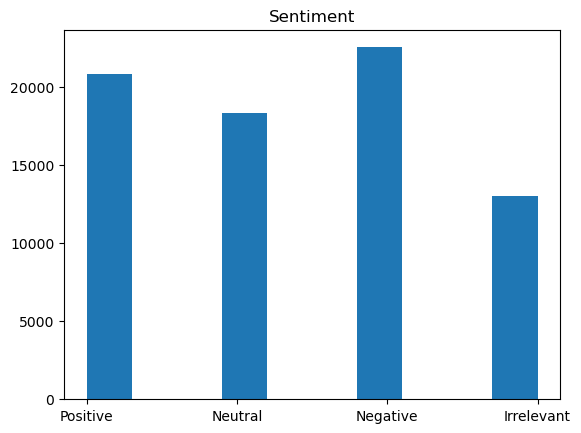

In [6]:
figure = plt.hist(df.Sentiment)
figure = plt.title('Sentiment')
plt.show()

In [7]:
# Series.str ermöglicht es auf die Werte der Series als Strings zuzugreifen und Stringoperationen anzuwenden
# lower(): Umwandlung in Kleinbuchstaben
df.Tweet = df.Tweet.str.lower()

# replace()
df.Tweet = df.Tweet.str.replace(r"https?://\S+|www\.\S+", "", regex=True) # URLs entfernen
df.Tweet = df.Tweet.str.replace(r"@\w+", "", regex=True) # @ Mentions entfernen
df.Tweet = df.Tweet.str.replace(r"[^\w\s]", "", regex=True) # alles entfernen, das nicht \w - alphanumerische Zeichen oder \s beliebiges Zeichen inkl. Tab und Space ist

In [8]:
df.tail()

,ID,Keyword,Sentiment,Tweet
74676,9200,Nvidia,Positive,just realized that the windows partition of my...
74677,9200,Nvidia,Positive,just realized that my mac window partition is ...
74678,9200,Nvidia,Positive,just realized the windows partition of my mac ...
74679,9200,Nvidia,Positive,just realized between the windows partition of...
74680,9200,Nvidia,Positive,just like the windows partition of my mac is l...


In [14]:
df.info()
df = df.dropna() # Zeilen mit fehlenden Werten löschen
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         73995 non-null  int64 
 1   Keyword    73995 non-null  object
 2   Sentiment  73995 non-null  object
 3   Tweet      73995 non-null  object
 4   tokens     73995 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.4+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         73995 non-null  int64 
 1   Keyword    73995 non-null  object
 2   Sentiment  73995 non-null  object
 3   Tweet      73995 non-null  object
 4   tokens     73995 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.4+ MB


## Wörter

In [37]:
# str.split um einzelne Wörter zu extrahieren
df["tokens"] = df["Tweet"].str.split()

# Alle Tokens aus allen Zeilen zu einer einzigen Liste zusammenführen
word_list = np.concatenate(df["tokens"].values)


word_counts = pd.Series(word_list).value_counts()
word_counts = word_counts.reset_index()
word_counts.columns = ["word", "count"]

# Häufigste Wörter:
word_counts.head()

,word,count
0,the,44445
1,i,29190
2,to,28830
3,and,26590
4,a,24109


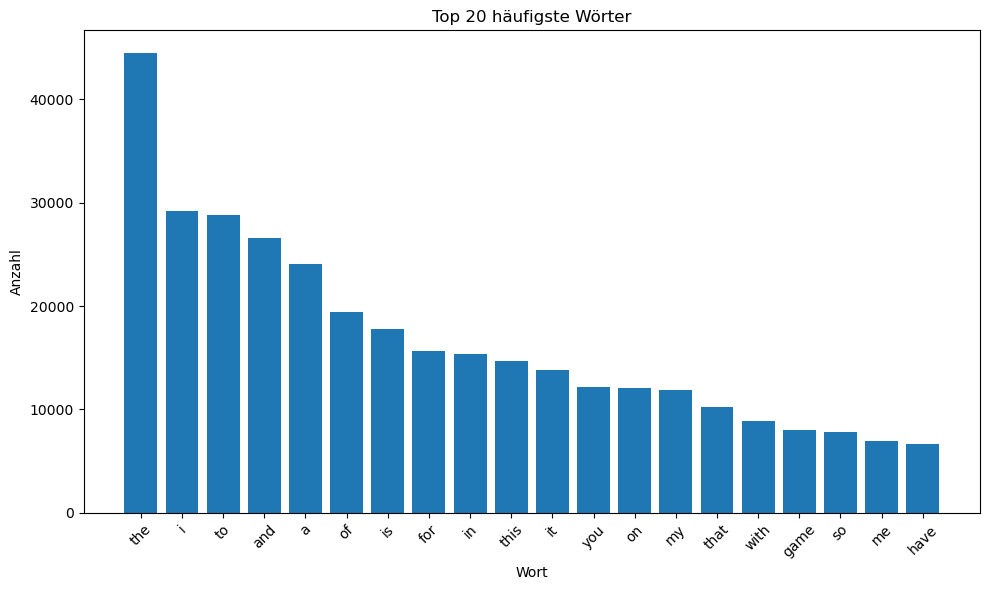

In [38]:
# Barchart Top 20 Wörter
top_n = 20
top_words = word_counts.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_words["word"], top_words["count"])
plt.title(f"Top {top_n} häufigste Wörter")
plt.xlabel("Wort")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()